# Humanitarian Gap Prediction — Mamba SSM v2
## Monthly INFORM sequences + Ben's Level 1-5 enriched features

**Data sources integrated:**
- `inform_severity_long.csv` — 65 monthly INFORM snapshots per crisis (2020-09 → 2026-03)
- `inform_indicators_long.csv` — monthly PIN phases, displacement, access per crisis
- Ben's `build_enriched_frame()` — Level 1-5 features: coverage ratios, donor HHI, cluster Gini, MAUT gap scores, temporal aggregates
- Ground-truth benchmarks: CERF UFE, CARE BTS

**Model input:** `(75 countries × 65 months × 4 features)` + 21 static context features  
**Sequences:** 24-month sliding window → predict next-month severity category + next-year funding gap


In [1]:
import warnings, sys, math
warnings.filterwarnings('ignore')
sys.path.insert(0, 'analysis')

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, roc_auc_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange, repeat

DATA   = Path('Data')
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device: mps
PyTorch: 2.5.1


## 1. Data Loading — Ben's Feature Pipeline

Load pre-built arrays from `analysis/features.py` (Levels 1-5) and the monthly INFORM trajectory matrices.

In [2]:
# ── Load pre-built arrays from Ben's feature pipeline ───────────────────────
X_monthly = np.load(DATA / 'monthly_severity_sequences.npy')   # (75, 65, 4)
ctx_arr   = np.load(DATA / 'context_features.npy')             # (75, 21)
countries  = pd.read_csv(DATA / 'sequence_countries.csv', header=None)[0].tolist()
snapshots  = pd.read_csv(DATA / 'sequence_snapshots.csv', header=None)[0].tolist()

# Load enriched frame (Level 1-5)
enriched = pd.read_csv(DATA / 'enriched_frame_2025.csv', index_col=0)

# Load benchmarks
cerf_ufe = pd.read_csv(DATA / 'Third-Party/Benchmarks/cerf_ufe.csv')
care_bts = pd.read_csv(DATA / 'Third-Party/Benchmarks/care_bts.csv')

N, T, F_seq = X_monthly.shape
F_ctx = ctx_arr.shape[1]
print(f'Monthly sequences:   {N} countries × {T} timesteps × {F_seq} features')
print(f'Context features:    {F_ctx} (Level 1-5)')
print(f'Date range:          {snapshots[0]} → {snapshots[-1]}')
print(f'NaN in sequences:    {np.isnan(X_monthly).mean():.4f}')
print(f'NaN in context:      {np.isnan(ctx_arr).mean():.4f}')


Monthly sequences:   75 countries × 65 timesteps × 4 features
Context features:    21 (Level 1-5)
Date range:          2020-09 → 2026-03
NaN in sequences:    0.0000
NaN in context:      0.3117


In [3]:
# ── Preprocessing ───────────────────────────────────────────────────────────
SEQ_LEN    = 24   # 24-month look-back window
PRED_STEPS = 3    # predict severity 3 months ahead

# Normalize sequences (per-feature, fit on first 48 months = training window)
seq_flat = X_monthly[:, :48, :].reshape(-1, F_seq)
seq_scaler = StandardScaler().fit(seq_flat)
X_norm = seq_scaler.transform(X_monthly.reshape(-1, F_seq)).reshape(N, T, F_seq).astype(np.float32)

# Normalize context (fit on full since it's static)
ctx_median = np.nanmedian(ctx_arr, axis=0)
for j in range(ctx_arr.shape[1]):
    ctx_arr[:, j] = np.where(np.isnan(ctx_arr[:, j]), ctx_median[j], ctx_arr[:, j])
ctx_scaler = StandardScaler().fit(ctx_arr)
ctx_norm = ctx_scaler.transform(ctx_arr).astype(np.float32)

# Build sliding-window sequences
# Target: next PRED_STEPS severity categories (regression on ordinal 1-5)
# Also: binary neglect label from enriched frame
seqs_X, seqs_ctx, seqs_y_sev, seqs_meta = [], [], [], []

# Severity (feature index 0) in normalized scale
sev_col_idx = 0  # category is first feature

for i, iso3 in enumerate(countries):
    seq = X_norm[i]      # (T, F_seq)
    ctx = ctx_norm[i]    # (F_ctx,)
    
    for t in range(SEQ_LEN, T - PRED_STEPS):
        X_window  = seq[t - SEQ_LEN:t]          # (24, 4)
        y_sev_raw = X_monthly[i, t:t+PRED_STEPS, sev_col_idx]  # raw category 1-5
        
        # Use mean of next PRED_STEPS months as target severity
        y_target = float(np.mean(y_sev_raw))
        
        seqs_X.append(X_window)
        seqs_ctx.append(ctx)
        seqs_y_sev.append(y_target)
        seqs_meta.append({'iso3': iso3, 'end_snapshot': snapshots[t], 'target_snapshot': snapshots[min(t+PRED_STEPS-1, T-1)]})

X_arr   = np.stack(seqs_X).astype(np.float32)      # (N_seq, 24, 4)
ctx_mat = np.stack(seqs_ctx).astype(np.float32)     # (N_seq, 21)
y_arr   = np.array(seqs_y_sev, dtype=np.float32)    # (N_seq,)
meta_df = pd.DataFrame(seqs_meta)

# Train/test split: sequences ending before 2025-01 = train
train_mask = meta_df['end_snapshot'] < '2025-01'
test_mask  = ~train_mask

train_idx = meta_df[train_mask].index.tolist()
test_idx  = meta_df[test_mask].index.tolist()

print(f'Total sequences: {len(X_arr)}')
print(f'  Train: {len(train_idx)} (up to 2024-12)')
print(f'  Test:  {len(test_idx)}  (2025-01 onwards)')
print(f'Feature shapes: X={X_arr.shape}, ctx={ctx_mat.shape}')
print(f'Target range: {y_arr.min():.2f} – {y_arr.max():.2f}  (severity category 1-5)')

# Neglect labels from enriched frame (coverage < 0.4)
neglect_map = {}
for iso3 in countries:
    if iso3 in enriched.index:
        cov = enriched.loc[iso3, 'coverage']
        gap = enriched.loc[iso3, 'gap_score_cerf_profile']
        neglect_map[iso3] = {
            'neglected': float(not pd.isna(cov) and cov < 0.4),
            'gap_score': float(gap) if not pd.isna(gap) else 0.5
        }

y_neglect = np.array([neglect_map.get(m['iso3'], {}).get('neglected', 0.5) for m in seqs_meta], dtype=np.float32)
y_gap     = np.array([neglect_map.get(m['iso3'], {}).get('gap_score', 0.5) for m in seqs_meta], dtype=np.float32)


Total sequences: 2850
  Train: 2025 (up to 2024-12)
  Test:  825  (2025-01 onwards)
Feature shapes: X=(2850, 24, 4), ctx=(2850, 21)
Target range: 2.00 – 5.00  (severity category 1-5)


## 2. Mamba2 Model — Context-Conditioned SSD

Context gate: static Level 1-5 features modulate the `dt` selectivity of each SSD layer.

In [4]:
# ── Mamba2-style SSD with context conditioning ───────────────────────────────
# Extended from v1: adds a context projection that modulates dt (the key
# selectivity gate in Mamba), allowing static Level 1-5 features to bias
# the sequence's attention toward relevant time steps.

class SSDLayer(nn.Module):
    def __init__(self, d_model, d_state=16, n_heads=4, d_conv=4, expand=2, d_ctx=0):
        super().__init__()
        self.d_model  = d_model
        self.d_state  = d_state
        self.n_heads  = n_heads
        self.d_inner  = d_model * expand
        self.d_head   = self.d_inner // n_heads
        assert self.d_inner % n_heads == 0

        dt_rank = max(1, d_model // 16)
        self.dt_rank = dt_rank
        self.in_proj = nn.Linear(d_model, self.d_inner * 2 + d_state * 2 + dt_rank, bias=False)
        self.dt_proj = nn.Linear(dt_rank, self.d_inner, bias=True)
        nn.init.uniform_(self.dt_proj.bias, -4, -1)

        A = repeat(torch.arange(1, d_state + 1, dtype=torch.float32), 'n -> h n', h=self.d_inner)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                padding=d_conv-1, groups=self.d_inner, bias=True)

        # Context gate: project d_ctx → d_inner to modulate dt
        self.ctx_gate = nn.Linear(d_ctx, self.d_inner, bias=True) if d_ctx > 0 else None

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

    def selective_scan(self, u, delta, A, B, C, D):
        B_batch, L, d = u.shape
        N = A.shape[1]
        delta_A   = torch.exp(rearrange(delta, 'b l d -> b l d 1') * rearrange(A, 'd n -> 1 1 d n'))
        delta_B_u = rearrange(delta, 'b l d -> b l d 1') * rearrange(B, 'b l n -> b l 1 n') * rearrange(u, 'b l d -> b l d 1')
        h  = torch.zeros(B_batch, d, N, device=u.device, dtype=u.dtype)
        ys = []
        for t in range(L):
            h   = delta_A[:, t] * h + delta_B_u[:, t]
            y_t = (h * rearrange(C[:, t], 'b n -> b 1 n')).sum(-1)
            ys.append(y_t)
        y = torch.stack(ys, dim=1)
        return y + u * D.unsqueeze(0).unsqueeze(0)

    def forward(self, x, ctx=None):
        # x: (B, L, d_model),  ctx: (B, d_ctx) optional
        residual = x
        B, L, _ = x.shape
        xz = self.in_proj(x)
        split_sizes = [self.d_inner, self.d_inner, self.d_state, self.d_state, self.dt_rank]
        x_ssm, z, B_ssm, C_ssm, dt = torch.split(xz, split_sizes, dim=-1)

        x_ssm = F.silu(self.conv1d(rearrange(x_ssm, 'b l d -> b d l'))[..., :L])
        x_ssm = rearrange(x_ssm, 'b d l -> b l d')

        dt_raw = self.dt_proj(dt)

        # Context modulation: add context bias before softplus to keep dt positive
        if self.ctx_gate is not None and ctx is not None:
            ctx_bias = self.ctx_gate(ctx).unsqueeze(1)  # (B, 1, d_inner)
            dt_raw = dt_raw + ctx_bias
        dt = F.softplus(dt_raw)

        A = -torch.exp(self.A_log)
        y = self.selective_scan(x_ssm, dt, A, B_ssm, C_ssm, self.D)
        y = torch.nan_to_num(y, nan=0.0, posinf=1.0, neginf=-1.0)
        y = self.out_proj(y * F.silu(z))
        return self.norm(y + residual)


class Mamba2Block(nn.Module):
    def __init__(self, d_model, d_state=16, n_heads=4, d_conv=4, expand=2, d_ctx=0):
        super().__init__()
        self.ssm = SSDLayer(d_model, d_state, n_heads, d_conv, expand, d_ctx=d_ctx)
        self.mlp = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model * 2, d_model),
        )

    def forward(self, x, ctx=None):
        x = self.ssm(x, ctx=ctx)
        return x + self.mlp(x)


class Mamba2Forecaster(nn.Module):
    """
    Context-conditioned Mamba2 for humanitarian severity & gap forecasting.

    Inputs:
      x   : (B, L, F_seq)  — monthly severity/displacement sequences
      ctx : (B, F_ctx)     — static Level 1-5 enriched features (Ben's pipeline)

    Outputs:
      sev_pred   : (B,)    — mean severity category next PRED_STEPS months
      gap_pred   : (B,)    — gap score (continuous)
      neglect_lg : (B,)    — neglect logit (binary)
    """
    def __init__(self, F_seq, F_ctx, d_model=48, n_layers=3, d_state=16, n_heads=4, d_conv=4, expand=2, dropout=0.15):
        super().__init__()
        self.ctx_proj    = nn.Sequential(nn.Linear(F_ctx, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.input_proj  = nn.Linear(F_seq, d_model)
        self.pos_emb     = nn.Parameter(torch.zeros(1, 64, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        self.blocks = nn.ModuleList([
            Mamba2Block(d_model, d_state, n_heads, d_conv, expand, d_ctx=d_model)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)

        # Pooling: concat last timestep + mean-pool for richer readout
        self.sev_head     = nn.Sequential(nn.Linear(d_model * 2, 32), nn.GELU(), nn.Linear(32, 1))
        self.gap_head     = nn.Sequential(nn.Linear(d_model * 2, 32), nn.GELU(), nn.Linear(32, 1))
        self.neglect_head = nn.Sequential(nn.Linear(d_model * 2, 32), nn.GELU(), nn.Linear(32, 1))

    def forward(self, x, ctx):
        B, L, _ = x.shape
        ctx_emb = self.ctx_proj(ctx)                      # (B, d_model)
        h = self.input_proj(x) + self.pos_emb[:, :L, :]
        h = self.dropout(h)
        for block in self.blocks:
            h = block(h, ctx=ctx_emb)
        h = self.norm(h)
        h_last = h[:, -1, :]
        h_mean = h.mean(dim=1)
        h_pool = torch.cat([h_last, h_mean], dim=-1)      # (B, 2*d_model)
        return (
            self.sev_head(h_pool).squeeze(-1),
            self.gap_head(h_pool).squeeze(-1),
            self.neglect_head(h_pool).squeeze(-1),
        )


model = Mamba2Forecaster(
    F_seq=F_seq, F_ctx=F_ctx,
    d_model=48, n_layers=3, d_state=16, n_heads=4, expand=2, dropout=0.15
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'Mamba2Forecaster — {total:,} parameters')
print(f'  Input: sequences (B, {SEQ_LEN}, {F_seq}) + context (B, {F_ctx})')
print(f'  Outputs: severity prediction, gap score, neglect logit')


Mamba2Forecaster — 110,739 parameters
  Input: sequences (B, 24, 4) + context (B, 21)
  Outputs: severity prediction, gap score, neglect logit


## 3. Dataset & Training

In [5]:
class MultiTargetDataset(Dataset):
    def __init__(self, X, ctx, y_sev, y_gap, y_neg):
        self.X     = torch.tensor(X,     dtype=torch.float32)
        self.ctx   = torch.tensor(ctx,   dtype=torch.float32)
        self.y_sev = torch.tensor(y_sev, dtype=torch.float32)
        self.y_gap = torch.tensor(y_gap, dtype=torch.float32)
        self.y_neg = torch.tensor(y_neg, dtype=torch.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.ctx[i], self.y_sev[i], self.y_gap[i], self.y_neg[i]


train_ds = MultiTargetDataset(
    X_arr[train_idx], ctx_mat[train_idx],
    y_arr[train_idx], y_gap[train_idx], y_neglect[train_idx]
)
test_ds = MultiTargetDataset(
    X_arr[test_idx], ctx_mat[test_idx],
    y_arr[test_idx], y_gap[test_idx], y_neglect[test_idx]
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

print(f'Train: {len(train_ds)} sequences,  Test: {len(test_ds)} sequences')
n_pos = y_neglect[train_idx].sum()
print(f'Neglect ratio in train: {n_pos/len(train_idx):.2%}')


Train: 2025 sequences,  Test: 825 sequences
Neglect ratio in train: 60.00%


In [6]:
EPOCHS   = 150
LR       = 8e-4
PATIENCE = 30
W_SEV, W_GAP, W_NEG = 0.5, 0.3, 0.2

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=3e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader), pct_start=0.15)

n_pos = float(y_neglect[train_idx].sum())
n_neg = float(len(train_idx)) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], dtype=torch.float32, device=DEVICE)

train_losses, test_losses, test_maes = [], [], []
best_loss, best_state, patience_ctr = float('inf'), None, 0

for epoch in range(EPOCHS):
    model.train()
    ep_loss = 0.0
    for X_b, ctx_b, y_sev_b, y_gap_b, y_neg_b in train_loader:
        X_b, ctx_b = X_b.to(DEVICE), ctx_b.to(DEVICE)
        y_sev_b, y_gap_b, y_neg_b = y_sev_b.to(DEVICE), y_gap_b.to(DEVICE), y_neg_b.to(DEVICE)

        sev_pred, gap_pred, neg_logit = model(X_b, ctx_b)
        loss_sev = F.huber_loss(sev_pred, y_sev_b, delta=0.5)
        loss_gap = F.huber_loss(gap_pred, y_gap_b, delta=0.5)
        loss_neg = F.binary_cross_entropy_with_logits(neg_logit, y_neg_b, pos_weight=pos_weight)
        loss = W_SEV * loss_sev + W_GAP * loss_gap + W_NEG * loss_neg

        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step(); scheduler.step()
        ep_loss += loss.item()

    model.eval()
    t_loss, all_sev_pred, all_sev_true = 0.0, [], []
    with torch.no_grad():
        for X_b, ctx_b, y_sev_b, y_gap_b, y_neg_b in test_loader:
            X_b, ctx_b = X_b.to(DEVICE), ctx_b.to(DEVICE)
            y_sev_b, y_gap_b, y_neg_b = y_sev_b.to(DEVICE), y_gap_b.to(DEVICE), y_neg_b.to(DEVICE)
            sev_pred, gap_pred, neg_logit = model(X_b, ctx_b)
            t_loss += (W_SEV * F.huber_loss(sev_pred, y_sev_b, delta=0.5) +
                       W_GAP * F.huber_loss(gap_pred, y_gap_b, delta=0.5) +
                       W_NEG * F.binary_cross_entropy_with_logits(neg_logit, y_neg_b, pos_weight=pos_weight)).item()
            all_sev_pred.extend(sev_pred.cpu().numpy())
            all_sev_true.extend(y_sev_b.cpu().numpy())

    tl  = t_loss / len(test_loader)
    mae = mean_absolute_error(all_sev_true, all_sev_pred)
    train_losses.append(ep_loss / len(train_loader))
    test_losses.append(tl)
    test_maes.append(mae)

    if tl < best_loss:
        best_loss, best_state, patience_ctr = tl, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stop at epoch {epoch}'); break

    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch:3d} | train: {train_losses[-1]:.4f} | test: {tl:.4f} | sev_MAE: {mae:.4f}')

model.load_state_dict(best_state)
print(f'\nBest model (test_loss={best_loss:.4f})')


Epoch   0 | train: 0.9566 | test: 0.9424 | sev_MAE: 3.4824
Epoch  20 | train: 0.0094 | test: 0.0137 | sev_MAE: 0.1598
Epoch  40 | train: 0.0061 | test: 0.0124 | sev_MAE: 0.1291
Early stop at epoch 54

Best model (test_loss=0.0111)


## 4. Evaluation

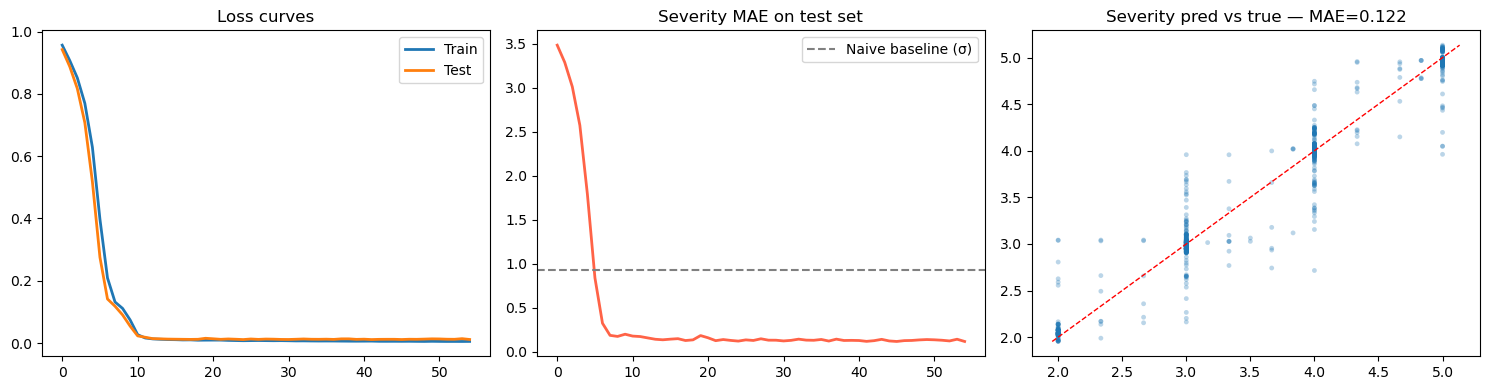

Severity MAE: 0.1224 (scale 1–5 ordinal)
Severity RMSE: 0.2223
Naive (predict mean) MAE: 0.8060


In [7]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(train_losses, label='Train', lw=2)
axes[0].plot(test_losses,  label='Test',  lw=2)
axes[0].set_title('Loss curves'); axes[0].legend()

axes[1].plot(test_maes, color='tomato', lw=2)
axes[1].axhline(np.std(y_arr[test_idx]), color='gray', ls='--', label='Naive baseline (σ)')
axes[1].set_title('Severity MAE on test set'); axes[1].legend()

# Predictions vs truth
model.eval()
all_sev_pred, all_sev_true, all_gap_pred, all_neg_prob = [], [], [], []
with torch.no_grad():
    for X_b, ctx_b, y_sev_b, y_gap_b, y_neg_b in test_loader:
        sev_pred, gap_pred, neg_logit = model(X_b.to(DEVICE), ctx_b.to(DEVICE))
        all_sev_pred.extend(sev_pred.cpu().numpy())
        all_sev_true.extend(y_sev_b.cpu().numpy())
        all_gap_pred.extend(gap_pred.cpu().numpy())
        all_neg_prob.extend(torch.sigmoid(neg_logit).cpu().numpy())

all_sev_pred = np.array(all_sev_pred)
all_sev_true = np.array(all_sev_true)
all_gap_pred = np.array(all_gap_pred)
all_neg_prob = np.array(all_neg_prob)

axes[2].scatter(all_sev_true, all_sev_pred, alpha=0.3, s=12, edgecolors='none')
lims = [min(all_sev_true.min(), all_sev_pred.min()), max(all_sev_true.max(), all_sev_pred.max())]
axes[2].plot(lims, lims, 'r--', lw=1)
mae_final = mean_absolute_error(all_sev_true, all_sev_pred)
axes[2].set_title(f'Severity pred vs true — MAE={mae_final:.3f}')
plt.tight_layout(); plt.savefig('mamba2_v2_training.png', dpi=150); plt.show()

print(f'Severity MAE: {mae_final:.4f} (scale 1–5 ordinal)')
print(f'Severity RMSE: {np.sqrt(mean_squared_error(all_sev_true, all_sev_pred)):.4f}')
print(f'Naive (predict mean) MAE: {mean_absolute_error(all_sev_true, np.full_like(all_sev_true, np.mean(all_sev_true))):.4f}')


## 5. Inference + External Validation

In [8]:
# ── Forward inference: predict next 3 months per country ────────────────────
model.eval()
results = []
for i, iso3 in enumerate(countries):
    seq_last = torch.tensor(X_norm[i, -SEQ_LEN:][None], dtype=torch.float32).to(DEVICE)
    ctx_t    = torch.tensor(ctx_norm[i][None], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        sev_pred, gap_pred, neg_logit = model(seq_last, ctx_t)

    # Current severity (last observed month, raw)
    current_sev = float(X_monthly[i, -1, 0])  # category 1-5
    predicted_sev = float(sev_pred.cpu())

    row = {'iso3': iso3, 'current_severity': current_sev, 'predicted_severity_3m': predicted_sev}

    # Enrich with Level 1-5 from enriched frame
    if iso3 in enriched.index:
        for col in ['coverage', 'coverage_shortfall', 'gap_score_balanced',
                    'gap_score_cerf_profile', 'cluster_gini', 'donor_hhi',
                    'completeness', 'median_rank', 'typology_cell',
                    'severity_baseline_24m', 'severity_acute_delta_3m',
                    'coverage_baseline_3y', 'coverage_trend_3y']:
            row[col] = enriched.loc[iso3, col] if col in enriched.columns else np.nan

    row['neglect_prob'] = float(torch.sigmoid(neg_logit).cpu())
    row['severity_worsening'] = max(0.0, predicted_sev - current_sev)
    results.append(row)

inf_df = pd.DataFrame(results)

# ── Composite score: Ben's CERF gap + model severity worsening ───────────────
def safe_norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0, index=s.index)

inf_df['sev_worsen_norm'] = safe_norm(inf_df['severity_worsening'].fillna(0))
inf_df['gap_norm']        = safe_norm(inf_df['gap_score_cerf_profile'].fillna(0))
inf_df['neglect_norm']    = safe_norm(inf_df['neglect_prob'].fillna(0))

inf_df['composite_score'] = (
    0.40 * inf_df['gap_norm'] +
    0.35 * inf_df['sev_worsen_norm'] +
    0.25 * inf_df['neglect_norm']
)

# Filter to confirmed crisis countries (severity_baseline >= 3)
crisis_mask = inf_df['severity_baseline_24m'].fillna(0) >= 3
ranking = inf_df[crisis_mask].sort_values('composite_score', ascending=False).reset_index(drop=True)
ranking['rank'] = ranking.index + 1

print(f'Crisis countries ranked: {len(ranking)}')
display_cols = ['iso3','rank','current_severity','predicted_severity_3m',
                'severity_worsening','coverage_shortfall','gap_score_cerf_profile',
                'typology_cell','composite_score']
display_cols = [c for c in display_cols if c in ranking.columns]
print(ranking[display_cols].head(20).to_string(index=False, float_format='{:.3f}'.format))


Crisis countries ranked: 66
iso3  rank  current_severity  predicted_severity_3m  severity_worsening  coverage_shortfall  gap_score_cerf_profile            typology_cell  composite_score
 SLV     1             3.000                  3.486               0.486               0.716                   0.468 contested-sector-starved            0.850
 UGA     2             3.000                  3.460               0.460               0.826                   0.402                        —            0.795
 SOM     3             5.000                  5.083               0.083               0.713                   0.708     consensus-overlooked            0.687
 COD     4             5.000                  5.080               0.080               0.728                   0.651       contested-balanced            0.651
 SDN     5             5.000                  4.983               0.000               0.605                   0.747 consensus-sector-starved            0.650
 MLI     6             5

In [9]:
# ── External validation against CERF UFE + CARE BTS benchmarks ─────────────
top5  = set(ranking['iso3'].head(5))
top10 = set(ranking['iso3'].head(10))
top15 = set(ranking['iso3'].head(15))

ufe_set = set(cerf_ufe['iso3'])
bts_set = set(care_bts['iso3'])

print('External validation (composite score ranking):')
print(f'  vs CERF UFE ({len(ufe_set)} countries):')
print(f'    Overlap@5:  {len(top5  & ufe_set)}/5  — {top5 & ufe_set}')
print(f'    Overlap@10: {len(top10 & ufe_set)}/10 — {top10 & ufe_set}')
print(f'    Overlap@15: {len(top15 & ufe_set)}/15 — {top15 & ufe_set}')
print(f'  vs CARE BTS ({len(bts_set)} countries):')
print(f'    Overlap@5:  {len(top5  & bts_set)}/5  — {top5 & bts_set}')
print(f'    Overlap@10: {len(top10 & bts_set)}/10 — {top10 & bts_set}')

# Also validate Ben's pure gap_score_cerf_profile ranking
ben_ranked = enriched['gap_score_cerf_profile'].dropna().sort_values(ascending=False)
ben_top5  = set(ben_ranked.head(5).index)
ben_top10 = set(ben_ranked.head(10).index)
print()
print("Ben's gap_score_cerf_profile ranking (no Mamba):")
print(f'  vs CERF UFE: @5={len(ben_top5 & ufe_set)}/5, @10={len(ben_top10 & ufe_set)}/10')
print(f'  vs CARE BTS: @5={len(ben_top5 & bts_set)}/5, @10={len(ben_top10 & bts_set)}/10')

# Typology breakdown
print()
print('Typology distribution in top-20:')
print(ranking.head(20)['typology_cell'].value_counts().to_string())


External validation (composite score ranking):
  vs CERF UFE (22 countries):
    Overlap@5:  3/5  — {'SDN', 'COD', 'SOM'}
    Overlap@10: 8/10 — {'BFA', 'COD', 'SOM', 'TCD', 'SDN', 'MOZ', 'HTI', 'MLI'}
    Overlap@15: 10/15 — {'BFA', 'COD', 'HND', 'YEM', 'SOM', 'TCD', 'SDN', 'MOZ', 'HTI', 'MLI'}
  vs CARE BTS (10 countries):
    Overlap@5:  0/5  — set()
    Overlap@10: 2/10 — {'BFA', 'MOZ'}

Ben's gap_score_cerf_profile ranking (no Mamba):
  vs CERF UFE: @5=4/5, @10=9/10
  vs CARE BTS: @5=0/5, @10=2/10

Typology distribution in top-20:
typology_cell
consensus-overlooked        5
contested-balanced          5
—                           4
consensus-sector-starved    4
contested-sector-starved    2


## 6. Export

In [10]:
# ── Export final ranked table ────────────────────────────────────────────────
out_cols = ['iso3','rank','current_severity','predicted_severity_3m','severity_worsening',
            'coverage_shortfall','gap_score_balanced','gap_score_cerf_profile',
            'cluster_gini','donor_hhi','completeness','typology_cell','composite_score']
out_cols = [c for c in out_cols if c in ranking.columns]
ranking[out_cols].to_csv(DATA / 'gap_ranking_mamba2_v2.csv', index=False, float_format='%.4f')
print('Saved: Data/gap_ranking_mamba2_v2.csv')
torch.save(model.state_dict(), 'mamba2_v2_model.pt')
print('Saved: mamba2_v2_model.pt')
print()
print(ranking[out_cols].head(20).to_string(index=False))


Saved: Data/gap_ranking_mamba2_v2.csv
Saved: mamba2_v2_model.pt

iso3  rank  current_severity  predicted_severity_3m  severity_worsening  coverage_shortfall  gap_score_balanced  gap_score_cerf_profile  cluster_gini  donor_hhi  completeness            typology_cell  composite_score
 SLV     1               3.0               3.486170            0.486170            0.716135            0.487671                0.467536      0.465422   0.799363      1.000000 contested-sector-starved         0.850359
 UGA     2               3.0               3.459525            0.459525            0.826170            0.305813                0.401645           NaN   0.578098      0.500000                        —         0.795499
 SOM     3               5.0               5.082619            0.082619            0.712894            0.576487                0.708346      0.263114   0.494038      1.000000     consensus-overlooked         0.687381
 COD     4               5.0               5.079669            0.07